# Control and trametinib response landscape

## tl;dr

94개 세포주의 DMSO 24h control과 trametinib response를 각각 PCA로 요약했다.
Response PC1은 저자 제공 외부 민감도와 Pearson `-0.599`, Spearman `-0.668`로
연관된다. PCA 축의 부호는 임의이므로 부호보다 연관 강도를 본다. 이 분석은 전체
코호트 탐색용이며 모델 선택에는 사용하지 않는다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/landscape_summary.json").read_text())
landscape = pd.read_csv(root / "results/tables/response_landscape.csv")
directions = pd.read_csv(root / "results/tables/direction_comparison.csv")
display(pd.DataFrame({
    "metric": [
        "cell lines", "control PC1 variance", "response PC1 variance",
        "response PC1 vs sensitivity Pearson", "response PC1 vs sensitivity Spearman",
        "median control-vs-drug cosine",
    ],
    "value": [
        summary["cell_lines"], summary["control_pc_explained_variance_ratio"][0],
        summary["response_pc_explained_variance_ratio"][0],
        summary["response_pc1_sensitivity_pearson"],
        summary["response_pc1_sensitivity_spearman"],
        summary["median_control_vs_drug_cosine"],
    ],
}))
assert len(landscape) == len(directions) == 94


,metric,value
0,cell lines,94.000000
1,control PC1 variance,0.129441
2,response PC1 variance,0.058855
3,response PC1 vs sensitivity Pearson,-0.598938
4,response PC1 vs sensitivity Spearman,-0.668273
5,median control-vs-drug cosine,-0.347920


## Context & Methods

### Key Assumptions

- 저자 제공 `all_CL_features.rds`의 Disease, sensitivity, mutation 필드를 DepMap ID로 연결했다.
- sensitivity와 mutation은 해석용이며 B0–B4 예측 입력이 아니다.
- PCA는 각 행렬에서 분산이 큰 5,000 genes를 사용한 전체 코호트 탐색 그림이다.
- DMSO 6→24h 변화와 drug response는 DMSO 24h를 반대 부호로 공유하므로 방향 비교는
  독립적인 인과 대조가 아니라 진단적 비교다.

## Results

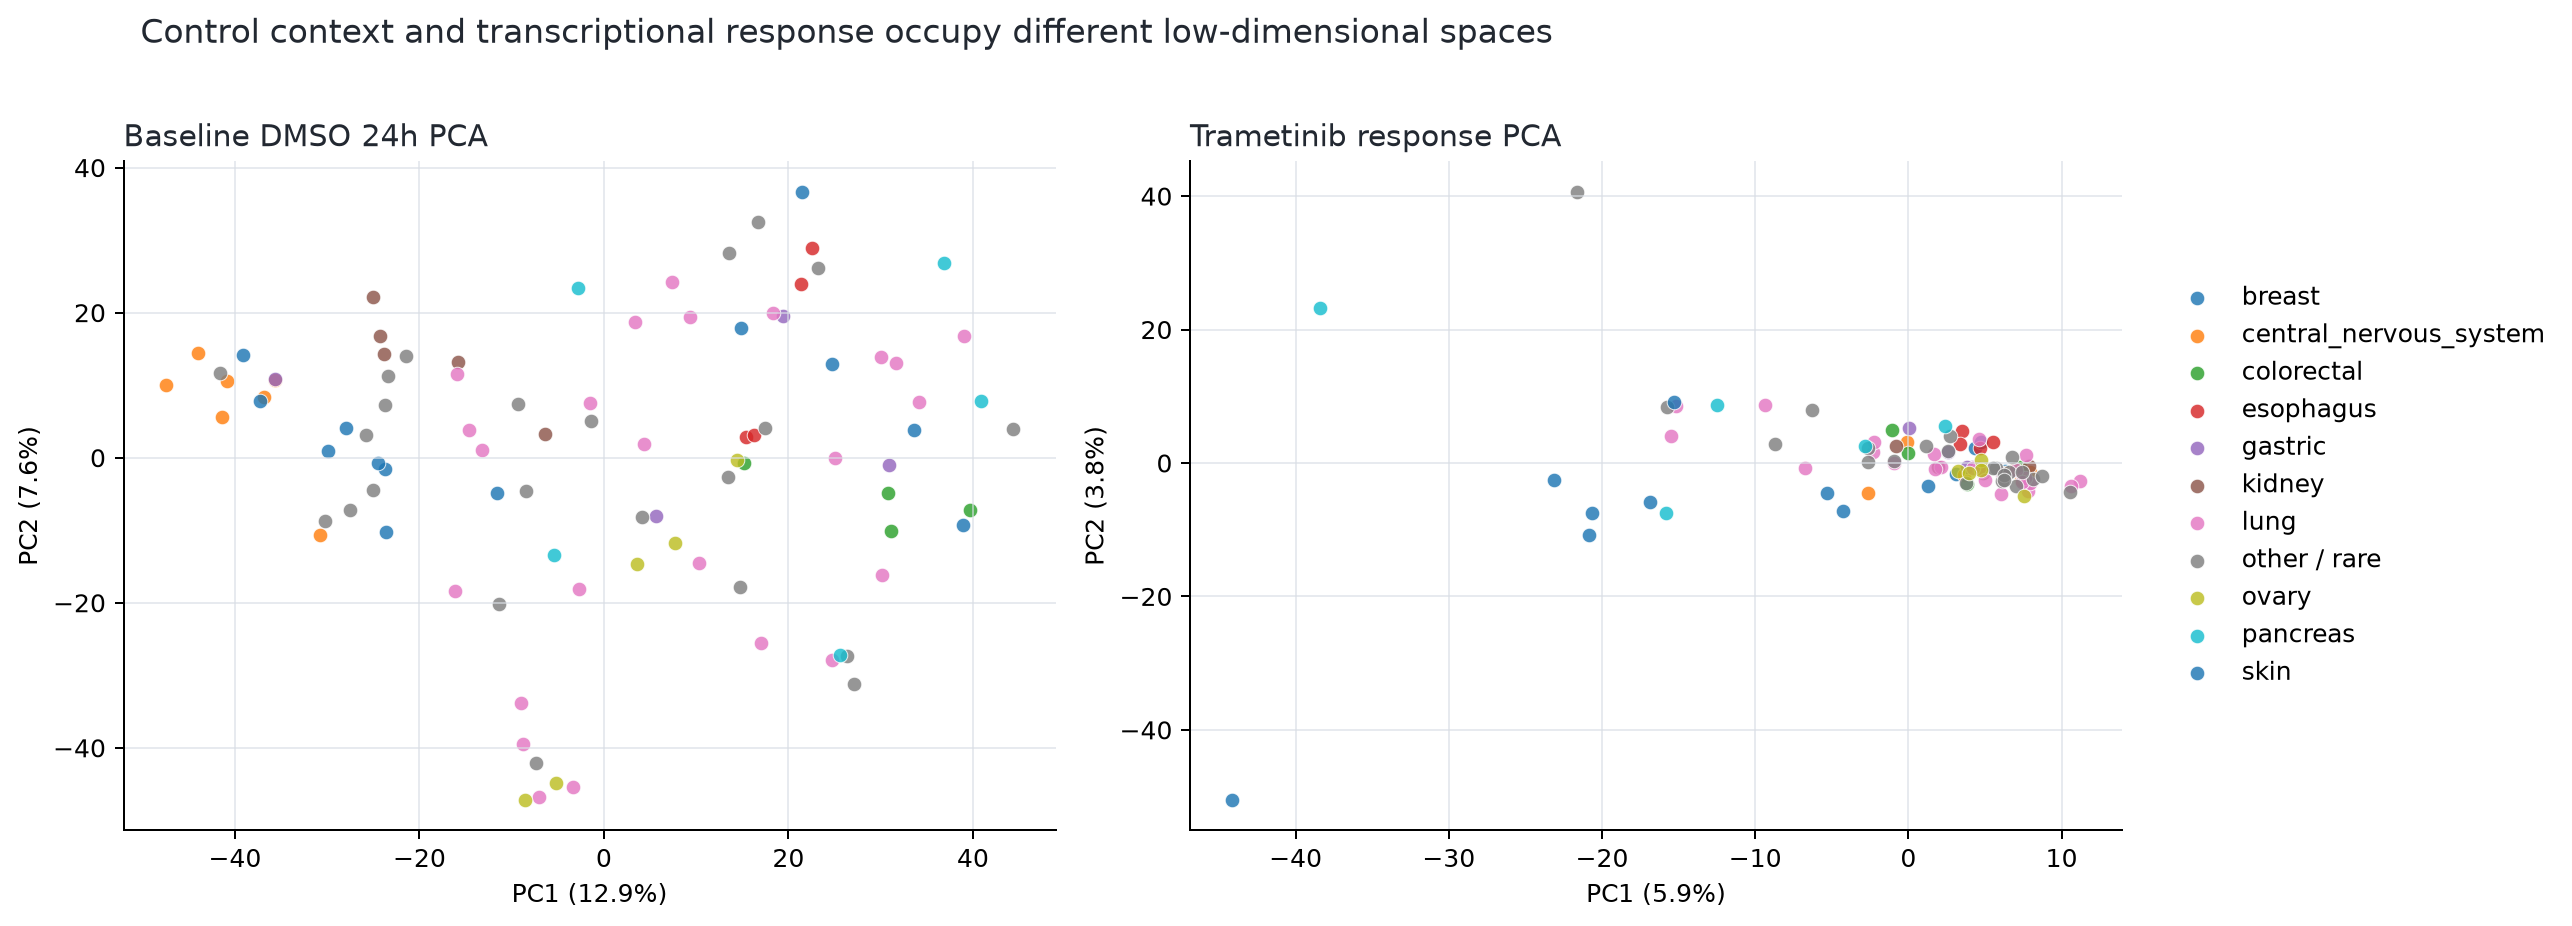

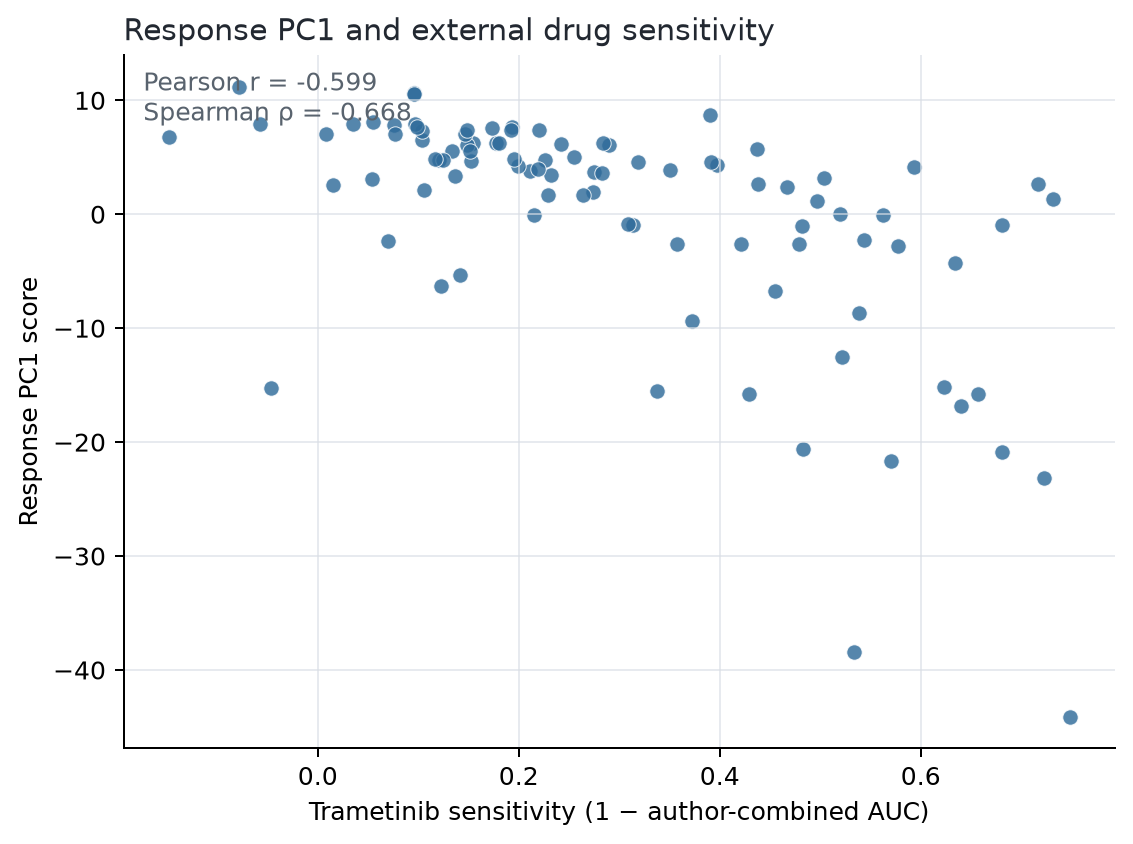

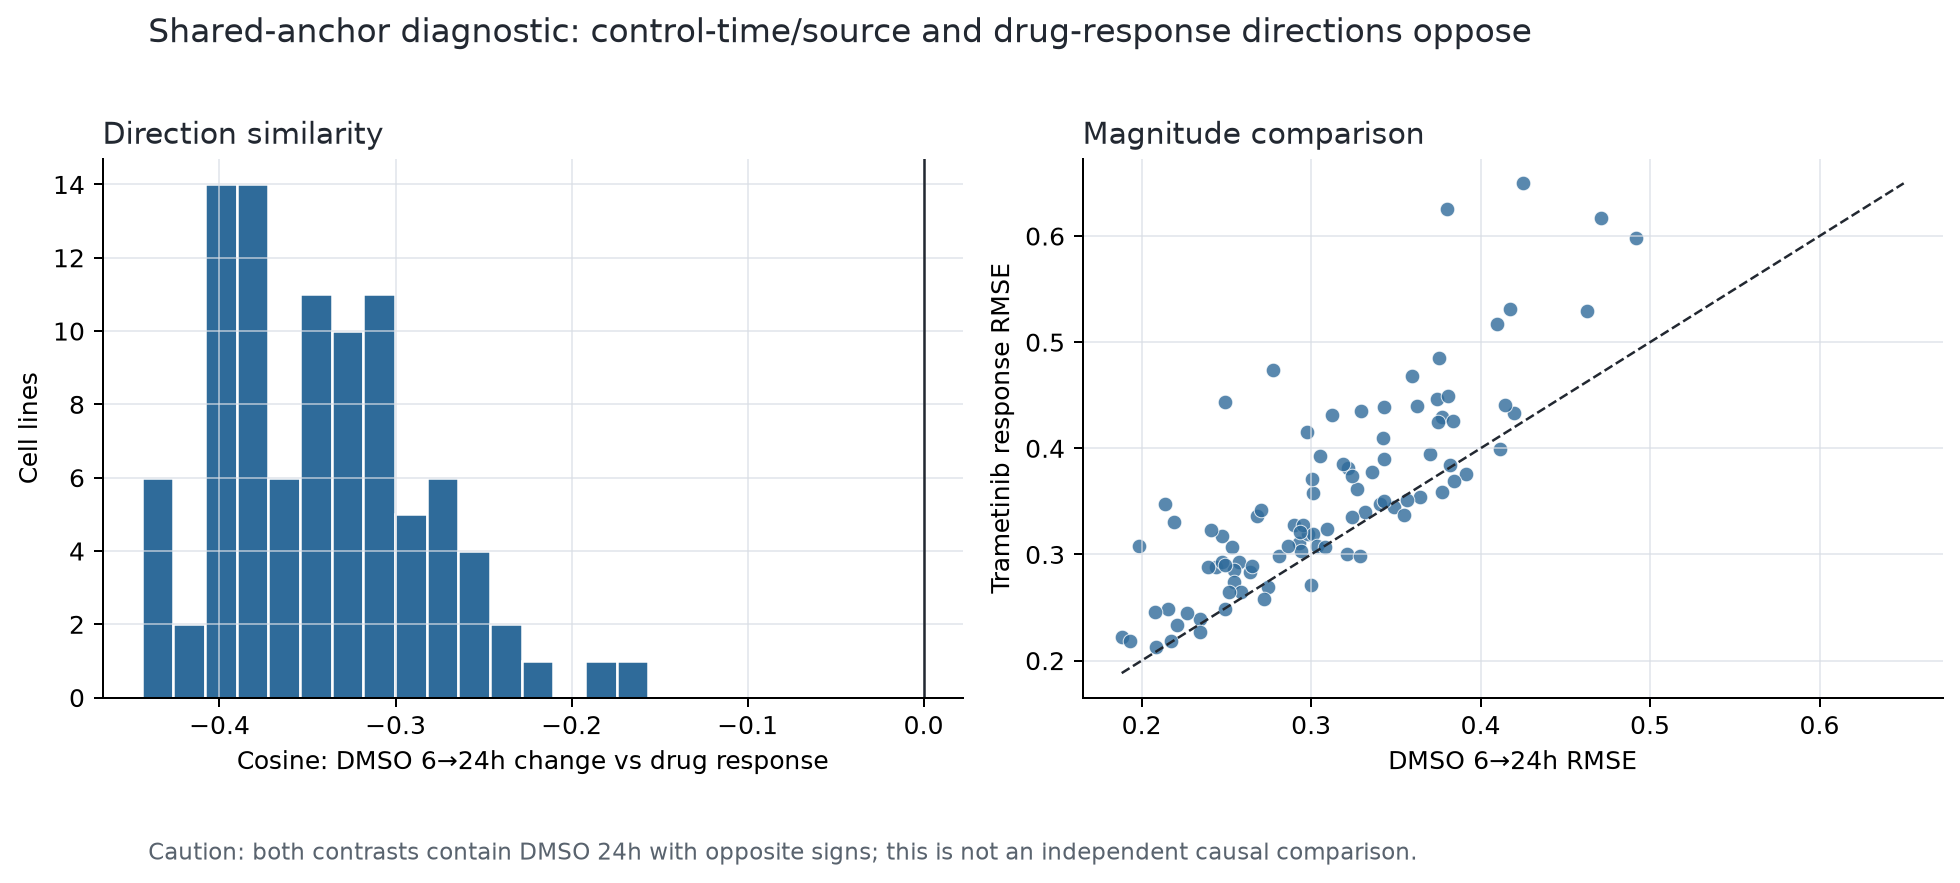

In [3]:
display(Image(filename=str(root / "results/figures/response_landscape.png")))
display(Image(filename=str(root / "results/figures/response_pc1_sensitivity.png")))
display(Image(filename=str(root / "results/figures/direction_comparison.png")))


## Takeaways

- baseline control PC1은 변동의 12.9%, response PC1은 5.9%를 설명한다.
- response의 주요 축은 외부 약물 민감도와 연결되므로 섭동 신호가 생물학적 차이를 담는다.
- control 시간/source 변화와 약물 반응은 크기가 비슷해도 방향은 같지 않다.
- 다만 공유 DMSO 24h anchor가 음의 유사도를 유도할 수 있어 방향 수치를
  독립 효과로 해석하지 않는다.